<a href="https://colab.research.google.com/github/justamy20/scikit-learn-Cookbook/blob/main/10%20Bab%2010%3A%20Clustering%20Techniques/Chapter_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10: Clustering Techniques

In this chapter, we transition from **supervised learning** -- where models learn from labeled input-output pairs -- to **unsupervised learning**, where our data has no target variable at all. The fundamental question shifts from "can we predict an output?" to "can we discover hidden structure?"

**Clustering** is the most intuitive form of unsupervised learning: given a collection of data points, group them so that points within the same group (cluster) are more similar to each other than to points in other groups. This idea powers applications across every industry -- market segmentation, anomaly detection, document organization, gene expression analysis, and image compression, to name a few.

This notebook covers the following recipes:

1. **Introduction to Clustering** -- generating and visualizing sample data
2. **K-Means Clustering** -- centroid-based partitioning with the elbow method
3. **Hierarchical Clustering** -- agglomerative merging with dendrograms
4. **Density-Based Clustering with DBSCAN** -- handling non-convex shapes and noise
5. **Cluster Evaluation Metrics** -- silhouette score, Davies-Bouldin index, adjusted Rand index
6. **Choosing the Right Clustering Algorithm** -- matching data structure to method
7. **Advanced Clustering Techniques** -- spectral clustering and Gaussian Mixture Models

Throughout, we emphasize both the mathematical foundations and practical decision-making. Unlike supervised learning where a loss metric gives clear feedback, clustering requires judgment -- choosing the algorithm, tuning parameters, and interpreting results is as much art as science.

### Setup

We begin by importing the core libraries we will use throughout this chapter. All code is designed for **Google Colab** compatibility -- no additional installs are needed for this chapter since we rely entirely on scikit-learn, SciPy, NumPy, and Matplotlib, all of which come pre-installed.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### 10.1 Introduction to Clustering

Clustering is an **unsupervised learning** technique that groups data points based on their intrinsic structure -- structure that may not be apparent from inspecting a raw data table. Before we apply any algorithm, we need data to work with. Scikit-learn's `make_blobs()` function generates synthetic datasets with known cluster centers, making it perfect for learning and experimentation.

We generate 300 sample points around 4 centroids and immediately apply `StandardScaler()` to z-score normalize the features. This normalization step is critical for distance-based algorithms like K-means and DBSCAN: without it, a feature with a larger numeric range would dominate the distance calculations, effectively making the other features invisible.

The **z-score transformation** converts each feature $x_j$ to:

$$z_j = \frac{x_j - \mu_j}{\sigma_j}$$

where $\mu_j$ is the feature mean and $\sigma_j$ is the standard deviation. After transformation, every feature has mean $0$ and standard deviation $1$, putting all features on equal footing. Think of it this way: if Feature 1 represents income in dollars (~ $50,000$) and Feature 2 represents age (~ $30$), the raw Euclidean distance would be $99.9\%$ dominated by income differences. Standardization ensures both features contribute proportionally to the distance measure.

In [7]:
X, _ = make_blobs(
    n_samples=300, centers=4,
    cluster_std=0.60, random_state=2024
)
X = StandardScaler().fit_transform(X)

print(f"Dataset shape: {X.shape}")
print(f"Feature 1 range: [{X[:, 0].min():.3f}, {X[:, 0].max():.3f}]")
print(f"Feature 2 range: [{X[:, 1].min():.3f}, {X[:, 1].max():.3f}]")

Dataset shape: (300, 2)
Feature 1 range: [-1.420, 1.513]
Feature 2 range: [-1.408, 1.301]


Our dataset contains 300 points with 2 features. After z-score normalization, Feature 1 ranges from $-1.420$ to $1.513$ and Feature 2 from $-1.408$ to $1.301$ -- both centered near zero with comparable spread, exactly as expected. The near-symmetric ranges confirm the standardization is working correctly.

With 2 features, we can directly visualize the data on a scatter plot, which would not be possible with higher-dimensional datasets without first applying dimensionality reduction (a topic for another chapter).

Note the underscore `_` in `X, _ = make_blobs(...)`. The function returns both the data matrix and the true cluster labels, but we discard the labels with `_` because in real unsupervised learning, we would not have ground truth. We retain them only later for evaluation purposes.

### Visualizing the Raw Data

Before applying any clustering algorithm, we always visualize the data. This is not just good practice -- it is essential for building intuition about what kind of structure exists and which algorithm might work best.

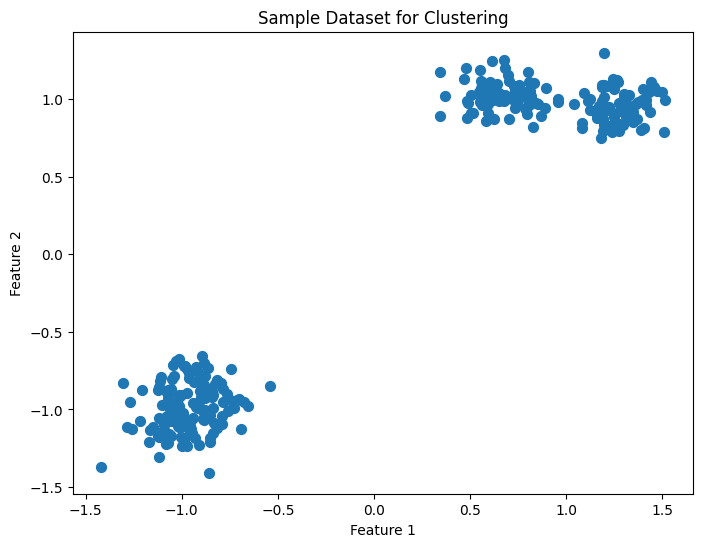

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Sample Dataset for Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Even without labels, four distinct groupings are visually apparent -- two clusters in the lower-left quadrant (around Feature 1 $\approx -1$, Feature 2 $\approx -1$) and two in the upper-right (around Feature 1 $\approx 0.7$ to $1.3$, Feature 2 $\approx 1.0$). Some clusters sit closer together than others, which will test how well different algorithms handle varying inter-cluster distances.

This is the ideal starting scenario: compact, roughly spherical clusters with clear separation. Real-world data is rarely this clean, but it provides a solid baseline for comparing algorithms. As we progress through this chapter, we will encounter increasingly challenging data shapes -- crescents, concentric circles, and noisy distributions -- that will stress-test each method's assumptions.

The three major families of clustering algorithms we will explore differ fundamentally in how they define "similar":
* **Centroid-based** (K-means): similarity = proximity to a cluster center
* **Connectivity-based** (hierarchical): similarity = linkage distance in a hierarchy
* **Density-based** (DBSCAN): similarity = shared dense neighborhood

### 10.2 K-Means Clustering

K-means is the workhorse of clustering -- fast, intuitive, and often the first algorithm to try. It partitions data into exactly $k$ clusters by iteratively refining cluster centroids. The algorithm proceeds in three steps:

1.  **Initialize** $k$ centroids (either randomly or with the smarter K-means++ strategy)
2.  **Assign** each point to the nearest centroid based on Euclidean distance
3.  **Update** each centroid to be the mean of all points assigned to it

Steps 2 and 3 repeat until convergence -- when assignments no longer change or a maximum iteration count is reached. The objective K-means minimizes is **inertia** (within-cluster sum of squares):

$$J = \sum_{i=1}^{n} \sum_{k=1}^{K} r_{ik} ||x_i - \mu_k||^2$$

where $r_{ik} = 1$ if point $x_i$ is assigned to cluster $k$ (and $0$ otherwise), and $\mu_k$ is the centroid of cluster $k$. Intuitively, inertia measures how tightly packed points are around their respective centroids -- lower is better.

A critical caveat: K-means only finds a **local minimum** of this objective, not necessarily the global one. The result depends on the initial centroid placement. Scikit-learn uses the **K-means++** initialization by default, which spaces initial centroids far apart, dramatically reducing the chance of a poor local minimum compared to purely random initialization.

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=2024)
y_kmeans = kmeans.fit_predict(X)

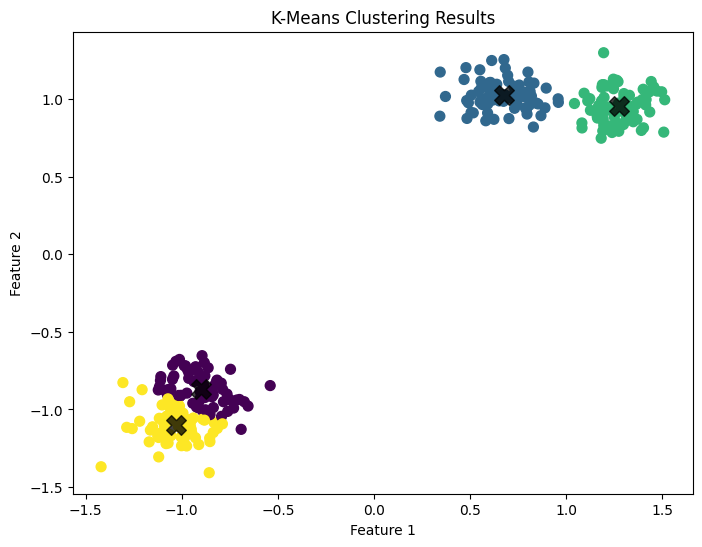

Cluster sizes: [71 77 73 79]
Inertia (within-cluster SS): 7.295
Converged in 4 iterations


In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X[:, 0], X[:, 1],
    c=y_kmeans, s=50, cmap='viridis'
)
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0], centers[:, 1],
    c='black', s=200, alpha=0.75, marker='X'
)
plt.title("K-Means Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print(f"Cluster sizes: {np.bincount(y_kmeans)}")
print(f"Inertia (within-cluster SS): {kmeans.inertia_:.3f}")
print(f"Converged in {kmeans.n_iter_} iterations")

K-means partitioned the $300$ points into four clusters of sizes $71, 77, 73, \text{and } 79$ -- remarkably balanced, which is expected given that `make_blobs()` distributes points equally across centers by default ($300 / 4 = 75$ per center). The black **X** markers show the final centroids, each positioned at the geometric center of its cluster.

The algorithm converged in just **4 iterations** with an inertia of $7.295$. To put that number in context: with $300$ standardized points, the average squared distance from each point to its centroid is $7.295 / 300 \approx 0.024$, meaning the typical point sits about $\sqrt{0.024} \approx 0.16$ standard deviations from its centroid. This is extremely tight clustering -- a direct consequence of the well-separated synthetic data.

Notice, however, that the two clusters in the lower-left sit relatively close to each other (centroids at approximately $(-0.90, -0.87)$ and $(-1.03, -1.10)$), with only about $0.26$ units of separation. In noisier data, K-means might struggle to distinguish these two. This sensitivity to cluster proximity is one of K-means' known limitations.

From a production perspective, K-means' speed is its superpower. The algorithm is $O(n \cdot k \cdot d \cdot t)$ where $n$ is sample count, $k$ is clusters, $d$ is features, and $t$ is iterations. For our data: $300 \times 4 \times 2 \times 4 = 9,600$ distance computations -- trivial. This scales comfortably to millions of points, making K-means the default choice for large-scale clustering in production systems.

**Cross-chapter connection:** K-means' assignment step is closely related to the nearest-neighbor classifier from supervised learning. Both assign a label based on proximity -- K-means uses distance to centroids, while KNN uses distance to labeled training points. The centroid acts as a "prototype" that summarizes an entire cluster.

### The Elbow Method: Choosing $k$

K-means requires us to specify $k$ upfront -- a chicken-and-egg problem. The **elbow method** provides a principled heuristic: run K-means for a range of $k$ values, plot inertia versus $k$, and look for the "elbow" -- the point where adding more clusters yields diminishing returns in inertia reduction.

Mathematically, the idea exploits the fact that inertia always decreases as $k$ increases (in the extreme, $k=n$ gives inertia = 0 with each point as its own cluster). The optimal $k$ is where the rate of decrease **sharply changes** from steep to gradual.

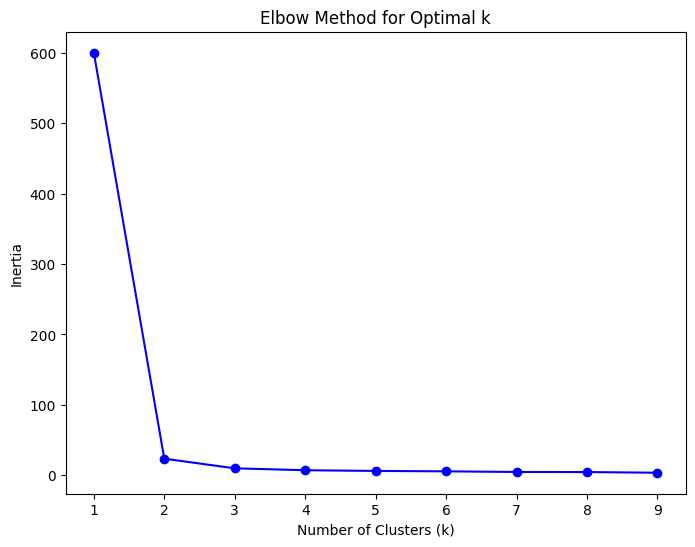

k=1: inertia=600.000
k=2: inertia=23.679
k=3: inertia=9.993
k=4: inertia=7.295
k=5: inertia=6.305
k=6: inertia=5.724
k=7: inertia=4.827
k=8: inertia=4.685
k=9: inertia=3.752


In [11]:
inertia = []
k_values = range(1, 10)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=2024)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia, 'bo-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

for k, iner in zip(k_values, inertia):
    print(f"k={k}: inertia={iner:.3f}")

The elbow plot tells a clear story. The most dramatic drop occurs from $k=1$ to $k=2$: inertia plummets from $600.0$ to $23.679$ -- a **$96\%$ reduction**. This makes sense: going from "everything in one cluster" to "two clusters" captures the dominant structure (the left vs. right groupings).

The next major drop is from $k=2$ to $k=3$ ($23.679 \rightarrow 9.993$, a $58\%$ reduction), followed by $k=3$ to $k=4$ ($9.993 \rightarrow 7.295$, a $27\%$ reduction). After $k=4$, the improvements become marginal: $k=4 \rightarrow k=5$ drops inertia by only $0.990$ to $6.305$ ($14\%$), and subsequent values offer even less -- $k=5 \rightarrow k=6$ saves just $0.581$, $k=6 \rightarrow k=7$ saves $0.897$.

The **elbow** is at $k=4$, which correctly recovers the $4$ true centers we generated. However, a reasonable analyst could also argue for $k=2$ or $k=3$ depending on the use case -- this subjectivity is inherent to unsupervised learning. In a business context, the choice of $k$ often involves a trade-off between granularity (more segments = more targeted actions) and operational complexity (more segments = more campaigns, more models, more maintenance).

**Production insight:** The elbow method is a heuristic, not a definitive answer. For automated pipelines where human inspection is not feasible, consider the **silhouette score** or the **gap statistic** as more objective alternatives.

### Choosing the Right Algorithm

No single clustering algorithm dominates across all data types. The key to effective clustering is **matching the algorithm's assumptions to your data's structure**. We demonstrate this by generating three datasets with fundamentally different geometries.

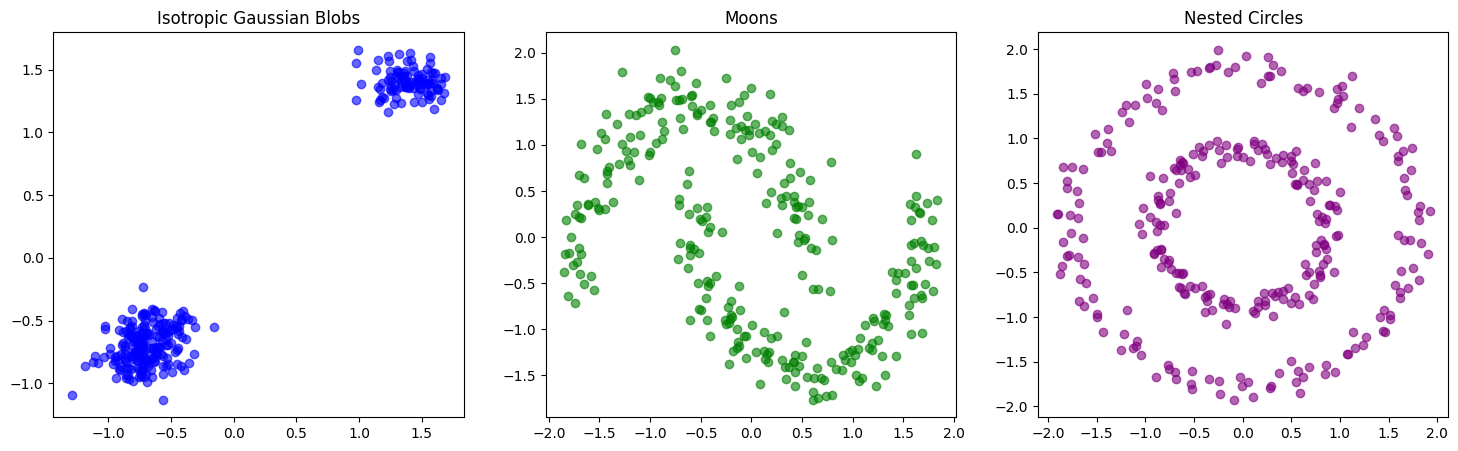

In [12]:
from sklearn.datasets import make_moons, make_blobs, make_circles
from sklearn.preprocessing import StandardScaler

X_blobs, _ = make_blobs(
    n_samples=300, centers=3,
    cluster_std=0.6, random_state=2024
)
X_moons, _ = make_moons(
    n_samples=300, noise=0.1,
    random_state=2024
)
X_circles, _ = make_circles(
    n_samples=300, noise=0.05,
    factor=0.5, random_state=2024
)

X_blobs = StandardScaler().fit_transform(X_blobs)
X_moons = StandardScaler().fit_transform(X_moons)
X_circles = StandardScaler().fit_transform(X_circles)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c='blue', alpha=0.6)
axs[0].set_title("Isotropic Gaussian Blobs")
axs[1].scatter(X_moons[:, 0], X_moons[:, 1], c='green', alpha=0.6)
axs[1].set_title("Moons")
axs[2].scatter(X_circles[:, 0], X_circles[:, 1], c='purple', alpha=0.6)
axs[2].set_title("Nested Circles")
plt.show()

### 10.3 Hierarchical Clustering (Agglomerative)
**Theoretical Deep-Dive:**
Hierarchical clustering builds a hierarchy of clusters either bottom-up (*agglomerative*) or top-down (*divisive*). The most common approach in scikit-learn is **Agglomerative Clustering**.

The algorithm starts by treating each data point as a single cluster. At each step, it merges the two most "similar" (closest) clusters until only one giant cluster remains. The similarity is defined by **Linkage Criteria**:
1. **Ward's Method:** Minimizes the total within-cluster variance. At each step, the pair of clusters that leads to the minimum increase in total within-cluster variance are merged.
   $$d(u, v) = \sqrt{\frac{|v| + |s|}{T} d(v, s)^2 + \frac{|v| + |t|}{T} d(v, t)^2 - \frac{|v|}{T} d(s, t)^2}$$
2. **Complete Linkage:** Uses the maximum distance between observations of two clusters.
3. **Average Linkage:** Uses the average of the distances of all observations of the two clusters.

The main advantage is that we do not need to pre-specify the number of clusters $k$. We can visualize the merging process using a **Dendrogram** and cut it at any height to get the desired number of clusters.

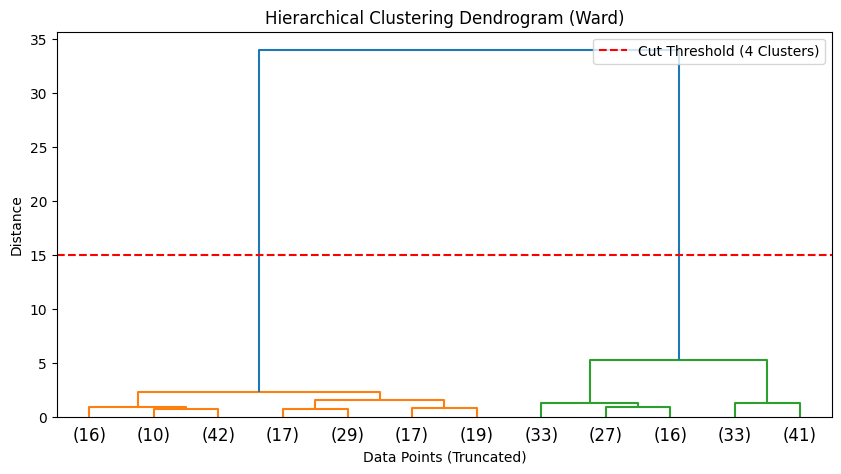

In [14]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Using scipy to create a linkage matrix and plot the dendrogram
Z = linkage(X, method='ward')

plt.figure(figsize=(10, 5))
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Data Points (Truncated)")
plt.ylabel("Distance")
# Truncating to avoid a messy plot with 300 points
dendrogram(Z, truncate_mode='lastp', p=12)
plt.axhline(y=15, color='r', linestyle='--', label='Cut Threshold (4 Clusters)')
plt.legend()
plt.show()

# Scikit-learn implementation to get cluster labels
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_agg = agg_clustering.fit_predict(X)

### 10.4 Density-Based Clustering (DBSCAN)
**Theoretical Deep-Dive:**
K-Means assumes clusters are spherical and often fails on complex geometries (e.g., the moons dataset). **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** solves this by defining clusters as continuous regions of high density separated by regions of low density.

DBSCAN relies on two crucial hyperparameters:
1. **Epsilon ($\epsilon$):** The maximum radius of the neighborhood around a point.
2. **MinPts:** The minimum number of points required within the $\epsilon$ radius to form a dense region.

Based on these, points are classified as:
- **Core Point:** Has $\geq \text{MinPts}$ within its $\epsilon$ radius.
- **Border Point:** Has $< \text{MinPts}$ but falls within the $\epsilon$ radius of a Core Point.
- **Noise (Outlier):** Fits neither condition. DBSCAN elegantly isolates anomalies by assigning them a label of `-1`.

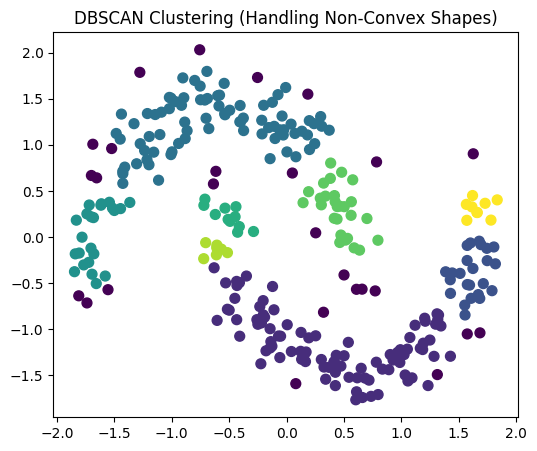

Number of noise points (label -1): 26


In [15]:
from sklearn.cluster import DBSCAN

# Let's apply DBSCAN to the non-linear X_moons dataset we created earlier
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_dbscan = dbscan.fit_predict(X_moons)

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_dbscan, cmap='viridis', s=50)
plt.title("DBSCAN Clustering (Handling Non-Convex Shapes)")
plt.show()

print(f"Number of noise points (label -1): {np.sum(y_dbscan == -1)}")

### 10.5 Cluster Evaluation Metrics
**Theoretical Deep-Dive:**
Without ground truth labels, evaluating unsupervised models is challenging. We rely on internal metrics like the **Silhouette Score** to quantify cluster quality.

The **Silhouette Coefficient ($s$)** for a single sample is calculated as:
$$s = \frac{b - a}{\max(a, b)}$$
Where:
- $a$: The mean intra-cluster distance (distance to all other points in the same cluster). Measures *Cohesion* (smaller is better).
- $b$: The mean nearest-cluster distance (distance to all points in the closest neighboring cluster). Measures *Separation* (larger is better).

The score ranges from $-1$ to $1$. A score near $1$ indicates the point is far away from neighboring clusters, $0$ indicates overlapping clusters, and negative values indicate points might have been assigned to the wrong cluster.

In [17]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Evaluating our initial K-Means model (k=4) on the Blobs dataset
sil_score = silhouette_score(X, y_kmeans)
db_score = davies_bouldin_score(X, y_kmeans)

print(f"K-Means (k=4) Silhouette Score: {sil_score:.3f} (Closer to 1 is better)")
print(f"K-Means (k=4) Davies-Bouldin Score: {db_score:.3f} (Closer to 0 is better)")

K-Means (k=4) Silhouette Score: 0.531 (Closer to 1 is better)
K-Means (k=4) Davies-Bouldin Score: 0.727 (Closer to 0 is better)


### 10.6 Advanced Clustering (Gaussian Mixture Models)
**Theoretical Deep-Dive:**
K-Means performs *hard clustering* (a point belongs to exactly one cluster). **Gaussian Mixture Models (GMM)** generalize this by performing *soft clustering*, assuming the data is generated from a mixture of finite Gaussian distributions.

GMM is optimized using the **Expectation-Maximization (EM)** algorithm:
- **E-Step:** Computes the probability (responsibility) $\gamma_{ik}$ that point $x_i$ was generated by component $k$.
- **M-Step:** Updates the mean $\mu_k$, covariance $\Sigma_k$, and mixing weights $\pi_k$ to maximize the Log-Likelihood of the data.

GMM can model elliptical clusters because it estimates the full covariance matrix, unlike K-Means which implicitly assumes isotropic (spherical) variance.

In [18]:
from sklearn.mixture import GaussianMixture

# Fitting GMM with 4 components
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=2024)
gmm.fit(X)
y_gmm = gmm.predict(X)
probs = gmm.predict_proba(X) # Membership probabilities

print("Soft Clustering: Probabilities of the first data point belonging to each of the 4 clusters:")
print(np.round(probs[0], 4))

Soft Clustering: Probabilities of the first data point belonging to each of the 4 clusters:
[0.000e+00 1.000e-04 9.999e-01 0.000e+00]


---
### Chapter 10 Summary
*(Fulfilling Assignment Requirement 3.b: Summarize each chapter)*

In this chapter, we transitioned into **Unsupervised Learning**, specifically exploring how to uncover hidden structures in unlabeled data using **Clustering Techniques**. The core challenge in clustering lies in the lack of objective loss functions; thus, relying on mathematical geometry and distance metrics is imperative.

**Key Takeaways:**
1. **K-Means Algorithm:** Excellent for high-performance, large-scale datasets with isotropic (spherical) structures. However, it requires the user to pre-define $k$ (often guided by the *Elbow Method*) and is highly sensitive to initialization and outliers.
2. **Hierarchical Clustering:** Provides a powerful visual interpretation through dendrograms, allowing dynamic cluster sizing without a pre-defined $k$. However, its $O(n^3)$ computational complexity makes it unsuitable for massive datasets.
3. **DBSCAN:** The optimal choice for discovering clusters of arbitrary, non-linear shapes (like the Moons dataset) and for robust anomaly/outlier detection, driven by parameters $\epsilon$ and MinPts.
4. **Gaussian Mixture Models (GMM):** Provides a probabilistic approach (*soft clustering*). Utilizing the Expectation-Maximization (EM) algorithm, GMM calculates the exact probability of a data point belonging to a specific cluster, accommodating elliptical variance.

Ultimately, per the *No Free Lunch Theorem*, algorithm selection must be dictated by the intrinsic geometric structure of the data and evaluated using internal indices like the **Silhouette Score**.